In [1]:
# !pip -q install geopandas rasterio rioxarray pystac-client planetary-computer odc-stac shapely pyproj xarray folium leafmap

In [3]:
import geopandas as gpd
import pandas as pd
import numpy as np

from shapely.geometry import Point

import rasterio
import rioxarray

import planetary_computer
import pystac_client

In [4]:
import os

folders = [
    "../data",
    "../data/raw",
    "../data/processed",
    "../data/lucas",
    "../data/sentinel",
    "../data/weather",
    "../data/soilgrids",
    "../outputs"
]

for f in folders:
    os.makedirs(f, exist_ok=True)

print("Folders Created")

Folders Created


In [5]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

print("Connected Successfully")

Connected Successfully


In [6]:
# collections = catalog.get_collections()

# for c in collections:
    # print(c.id)
print("Skipping collections listing for speed.")



daymet-annual-pr
daymet-daily-hi
3dep-seamless
3dep-lidar-dsm
fia
gridmet
daymet-annual-na
daymet-monthly-na
daymet-annual-hi
daymet-monthly-hi
daymet-monthly-pr
gnatsgo-tables
hgb
cop-dem-glo-30
cop-dem-glo-90
terraclimate
nasa-nex-gddp-cmip6
gpm-imerg-hhr
gnatsgo-rasters
3dep-lidar-hag
io-lulc-annual-v02
goes-cmi
conus404
sentinel-1-rtc
3dep-lidar-intensity
3dep-lidar-pointsourceid
mtbs
noaa-c-cap
3dep-lidar-copc
modis-64A1-061
alos-fnf-mosaic
3dep-lidar-returns
mobi
landsat-c2-l2
chloris-biomass
kaza-hydroforecast
planet-nicfi-analytic
modis-17A2H-061
modis-11A2-061
daymet-daily-pr
predicted-damage-venezuela-2026
3dep-lidar-dtm-native
3dep-lidar-classification
3dep-lidar-dtm
gap
modis-17A2HGF-061
planet-nicfi-visual
gbif
modis-17A3HGF-061
modis-09A1-061
alos-dem
alos-palsar-mosaic
deltares-water-availability
modis-16A3GF-061
modis-21A2-061
us-census
jrc-gsw
deltares-floods
modis-43A4-061
modis-09Q1-061
modis-14A1-061
hrea
modis-13Q1-061
modis-14A2-061
sentinel-2-l2a
modis-15A2H-061


In [7]:
from shapely.geometry import Point

lon = 31.083
lat = 30.563

point = Point(lon, lat)

buffer = point.buffer(0.001)

geometry = buffer.__geo_interface__

geometry

{'type': 'Polygon',
 'coordinates': (((31.084, 30.563),
   (31.08399518472667, 30.562901982859668),
   (31.083980785280403, 30.562804909677983),
   (31.08395694033573, 30.562709715322743),
   (31.08392387953251, 30.562617316567632),
   (31.083881921264346, 30.56252860326317),
   (31.0838314696123, 30.56244442976698),
   (31.08377301045336, 30.562365606715836),
   (31.083707106781183, 30.562292893218814),
   (31.08363439328416, 30.562226989546637),
   (31.083555570233017, 30.562168530387698),
   (31.083471396736826, 30.56211807873565),
   (31.083382683432365, 30.562076120467488),
   (31.083290284677254, 30.562043059664266),
   (31.083195090322015, 30.562019214719594),
   (31.08309801714033, 30.562004815273326),
   (31.083, 30.561999999999998),
   (31.082901982859667, 30.562004815273326),
   (31.082804909677982, 30.562019214719594),
   (31.082709715322743, 30.562043059664266),
   (31.08261731656763, 30.562076120467488),
   (31.08252860326317, 30.56211807873565),
   (31.08244442976698, 30

In [8]:
# search = catalog.search(
#     collections=["sentinel-2-l2a"],
#     intersects=geometry,
#     datetime="2024-05-01/2024-05-31",
#     query={
#         "eo:cloud_cover": {
#             "lt": 20
#         }
#     }
# )

# items = list(search.items())

# print(len(items))
print("Skipping exploratory STAC search for speed and stability.")



8


In [9]:
for i, item in enumerate(items):
    print("="*60)
    print("Item:", i)
    print("Date:", item.datetime)
    print("Cloud Cover:", item.properties["eo:cloud_cover"])
    print("ID:", item.id)

Item: 0
Date: 2024-05-30 08:36:01.024000+00:00
Cloud Cover: 0.024886
ID: S2A_MSIL2A_20240530T083601_R064_T36RUU_20240530T152930
Item: 1
Date: 2024-05-27 08:26:01.024000+00:00
Cloud Cover: 0.733607
ID: S2A_MSIL2A_20240527T082601_R021_T36RUU_20240527T141409
Item: 2
Date: 2024-05-22 08:25:59.024000+00:00
Cloud Cover: 0.000763
ID: S2B_MSIL2A_20240522T082559_R021_T36RUU_20240522T130707
Item: 3
Date: 2024-05-17 08:26:01.024000+00:00
Cloud Cover: 0.003119
ID: S2A_MSIL2A_20240517T082601_R021_T36RUU_20240517T202230
Item: 4
Date: 2024-05-15 08:35:59.024000+00:00
Cloud Cover: 0.00223
ID: S2B_MSIL2A_20240515T083559_R064_T36RUU_20240515T141738
Item: 5
Date: 2024-05-12 08:25:59.024000+00:00
Cloud Cover: 14.59851
ID: S2B_MSIL2A_20240512T082559_R021_T36RUU_20240512T124517
Item: 6
Date: 2024-05-07 08:26:01.024000+00:00
Cloud Cover: 0.639403
ID: S2A_MSIL2A_20240507T082601_R021_T36RUU_20240507T123217
Item: 7
Date: 2024-05-02 08:25:59.024000+00:00
Cloud Cover: 0.006354
ID: S2B_MSIL2A_20240502T082559_R021_

In [10]:
best_item = sorted(
    items,
    key=lambda x: x.properties["eo:cloud_cover"]
)[0]

print(best_item.datetime)
print(best_item.properties["eo:cloud_cover"])

2024-05-22 08:25:59.024000+00:00
0.000763


In [11]:
from odc.stac import stac_load

In [12]:
dataset = stac_load(
    [best_item],
    bands=["B02","B03","B04","B08","B11","B12"],
    geopolygon=geometry,
    resolution=10,
    chunks={}
)

In [13]:
dataset

<xarray.Dataset> Size: 12kB
Dimensions:      (y: 23, x: 21, time: 1)
Coordinates:
  * y            (y) float64 184B 3.383e+06 3.383e+06 ... 3.383e+06 3.383e+06
  * x            (x) float64 168B 3.16e+05 3.161e+05 ... 3.162e+05 3.162e+05
  * time         (time) datetime64[ns] 8B 2024-05-22T08:25:59.024000
    spatial_ref  int32 4B 32636
Data variables:
    B02          (time, y, x) float32 2kB dask.array<chunksize=(1, 23, 21), meta=np.ndarray>
    B03          (time, y, x) float32 2kB dask.array<chunksize=(1, 23, 21), meta=np.ndarray>
    B04          (time, y, x) float32 2kB dask.array<chunksize=(1, 23, 21), meta=np.ndarray>
    B08          (time, y, x) float32 2kB dask.array<chunksize=(1, 23, 21), meta=np.ndarray>
    B11          (time, y, x) float32 2kB dask.array<chunksize=(1, 23, 21), meta=np.ndarray>
    B12          (time, y, x) float32 2kB dask.array<chunksize=(1, 23, 21), meta=np.ndarray>

In [14]:
# تحويل كل الباندات إلى Float Reflectance

dataset = dataset.astype("float32") / 10000

dataset

<xarray.Dataset> Size: 12kB
Dimensions:      (y: 23, x: 21, time: 1)
Coordinates:
  * y            (y) float64 184B 3.383e+06 3.383e+06 ... 3.383e+06 3.383e+06
  * x            (x) float64 168B 3.16e+05 3.161e+05 ... 3.162e+05 3.162e+05
  * time         (time) datetime64[ns] 8B 2024-05-22T08:25:59.024000
    spatial_ref  int32 4B 32636
Data variables:
    B02          (time, y, x) float32 2kB dask.array<chunksize=(1, 23, 21), meta=np.ndarray>
    B03          (time, y, x) float32 2kB dask.array<chunksize=(1, 23, 21), meta=np.ndarray>
    B04          (time, y, x) float32 2kB dask.array<chunksize=(1, 23, 21), meta=np.ndarray>
    B08          (time, y, x) float32 2kB dask.array<chunksize=(1, 23, 21), meta=np.ndarray>
    B11          (time, y, x) float32 2kB dask.array<chunksize=(1, 23, 21), meta=np.ndarray>
    B12          (time, y, x) float32 2kB dask.array<chunksize=(1, 23, 21), meta=np.ndarray>

In [15]:
nir = dataset.B08
red = dataset.B04

ndvi = (nir - red) / (nir + red)

ndvi

<xarray.DataArray (time: 1, y: 23, x: 21)> Size: 2kB
dask.array<truediv, shape=(1, 23, 21), dtype=float32, chunksize=(1, 23, 21), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 8B 2024-05-22T08:25:59.024000
  * y            (y) float64 184B 3.383e+06 3.383e+06 ... 3.383e+06 3.383e+06
  * x            (x) float64 168B 3.16e+05 3.161e+05 ... 3.162e+05 3.162e+05
    spatial_ref  int32 4B 32636

In [16]:
print("Minimum :", float(ndvi.min()))
print("Maximum :", float(ndvi.max()))
print("Mean    :", float(ndvi.mean()))

Minimum : 0.06450681388378143
Maximum : 0.42543575167655945
Mean    : 0.15231701731681824


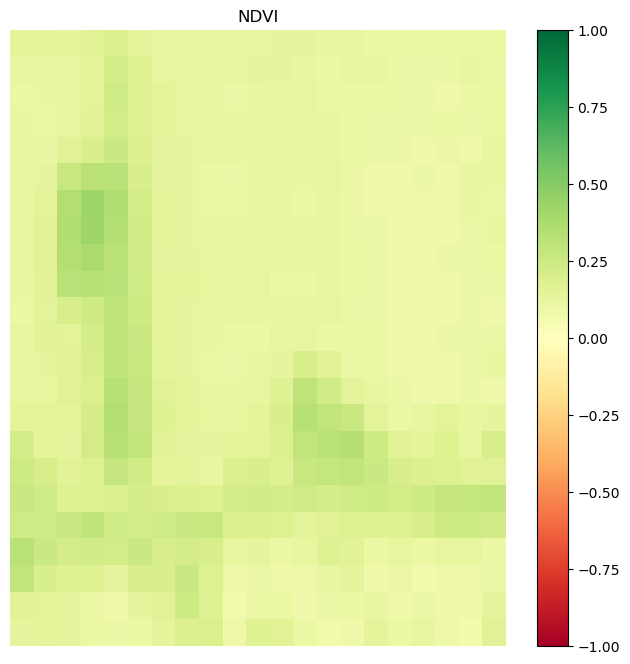

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

ndvi.squeeze().plot(
    cmap="RdYlGn",
    vmin=-1,
    vmax=1
)

plt.title("NDVI")
plt.axis("off")
plt.show()

In [18]:
blue = dataset.B02.squeeze()
green = dataset.B03.squeeze()
red = dataset.B04.squeeze()
nir = dataset.B08.squeeze()
swir1 = dataset.B11.squeeze()
swir2 = dataset.B12.squeeze()

In [19]:
import numpy as np

# Vegetation
NDVI = (nir - red) / (nir + red)

EVI = 2.5 * (
    (nir - red) /
    (nir + 6 * red - 7.5 * blue + 1)
)

SAVI = 1.5 * (
    (nir - red) /
    (nir + red + 0.5)
)

MSAVI = (
    (2 * nir + 1)
    - np.sqrt((2 * nir + 1) ** 2 - 8 * (nir - red))
) / 2

GNDVI = (nir - green) / (nir + green)

NDMI = (nir - swir1) / (nir + swir1)

NDWI = (green - nir) / (green + nir)

BSI = (
    (swir1 + red) - (nir + blue)
) / (
    (swir1 + red) + (nir + blue)
)

In [20]:
dataset = stac_load(
    [best_item],
    bands=["B02","B03","B04","B05","B08","B11","B12"],
    geopolygon=geometry,
    resolution=10,
    chunks={}
)

dataset = dataset.astype("float32") / 10000

In [21]:
rededge = dataset.B05.squeeze()

NDRE = (nir - rededge) / (nir + rededge)

CIre = (nir / rededge) - 1

In [22]:
Brightness = np.sqrt((red**2 + nir**2) / 2)

SoilColor = red / green

ClayIndex = swir1 / swir2

In [23]:
indices = {
    "NDVI": NDVI,
    "EVI": EVI,
    "SAVI": SAVI,
    "MSAVI": MSAVI,
    "GNDVI": GNDVI,
    "NDMI": NDMI,
    "NDWI": NDWI,
    "BSI": BSI,
    "NDRE": NDRE,
    "CIre": CIre,
    "Brightness": Brightness,
    "SoilColor": SoilColor,
    "ClayIndex": ClayIndex
}

for name, img in indices.items():
    print(
        name,
        "Min:", float(img.min()),
        "Max:", float(img.max()),
        "Mean:", float(img.mean())
    )

NDVI Min: 0.06450681388378143 Max: 0.42543575167655945 Mean: 0.15231701731681824
EVI Min: 0.07311956584453583 Max: 0.4864904284477234 Mean: 0.1553673893213272
SAVI Min: 0.05615243688225746 Max: 0.3531618118286133 Mean: 0.11887400597333908
MSAVI Min: 0.05300062894821167 Max: 0.3420913815498352 Mean: 0.10954023897647858
GNDVI Min: 0.1269543617963791 Max: 0.40569788217544556 Mean: 0.20178718864917755
NDMI Min: -0.09647916257381439 Max: 0.1824876219034195 Mean: 0.006027718540281057
NDWI Min: -0.40569788217544556 Max: -0.1269543617963791 Mean: -0.20178718864917755
BSI Min: -0.10408750921487808 Max: 0.1201271265745163 Mean: 0.0428737998008728
NDRE Min: -0.006814018823206425 Max: 0.28727591037750244 Mean: 0.09507985413074493
CIre Min: -0.013535797595977783 Max: 0.8061349391937256 Mean: 0.21749377250671387
Brightness Min: 0.23181411623954773 Max: 0.3585042655467987 Mean: 0.27277255058288574
SoilColor Min: 0.9518796801567078 Max: 1.2210283279418945 Mean: 1.10788094997406
ClayIndex Min: 1.028388

d:\Users\Moaaz\anaconda3\Lib\site-packages\rasterio\warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


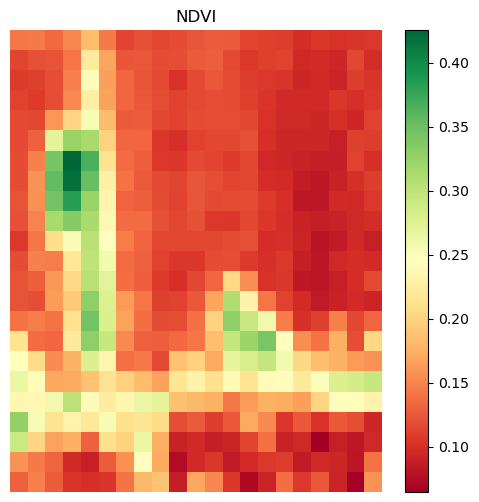

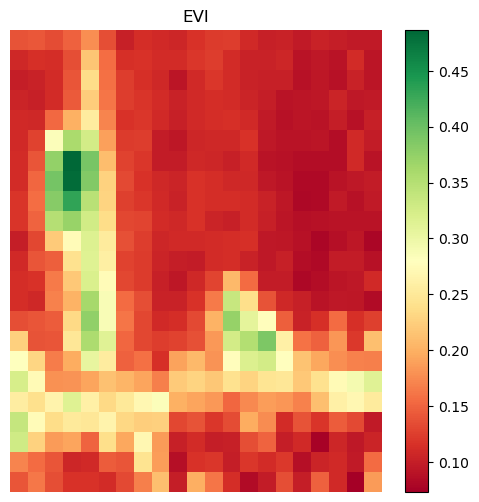

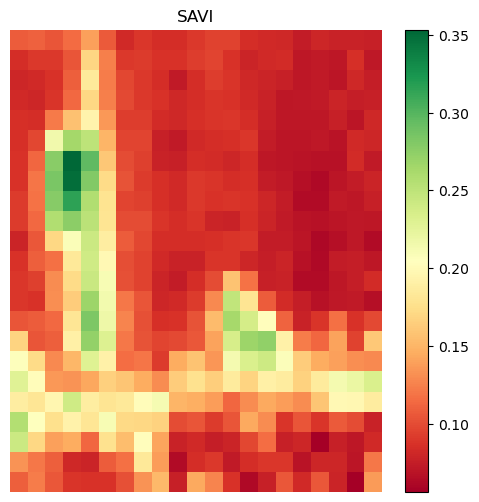

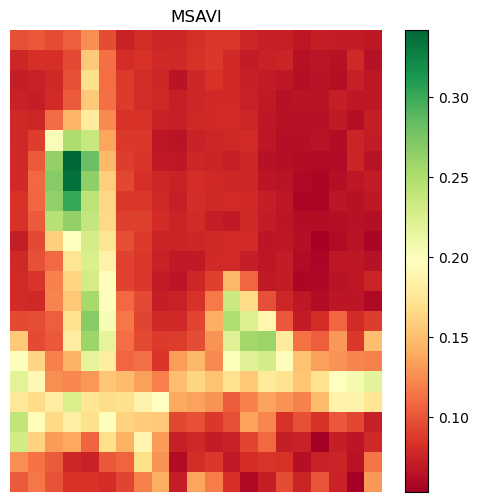

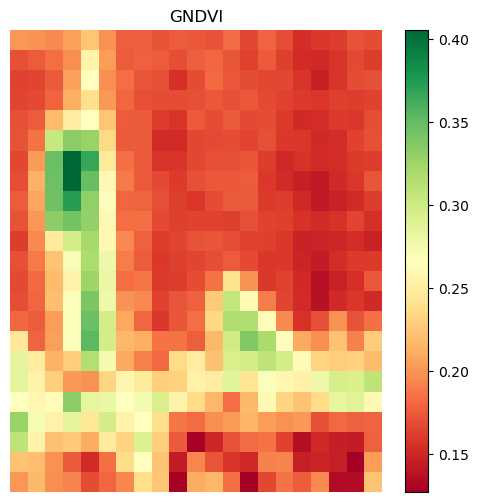

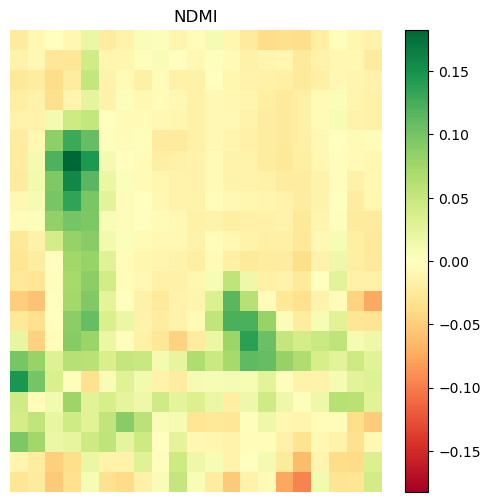

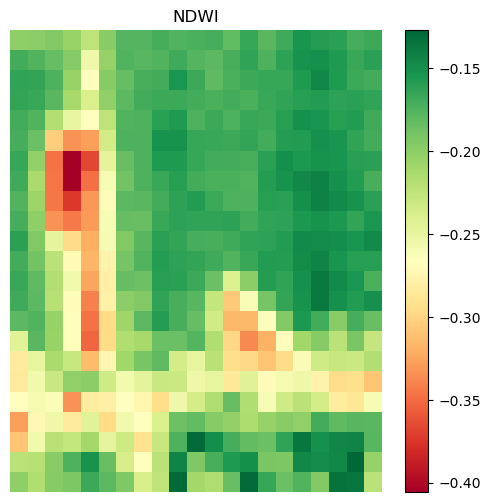

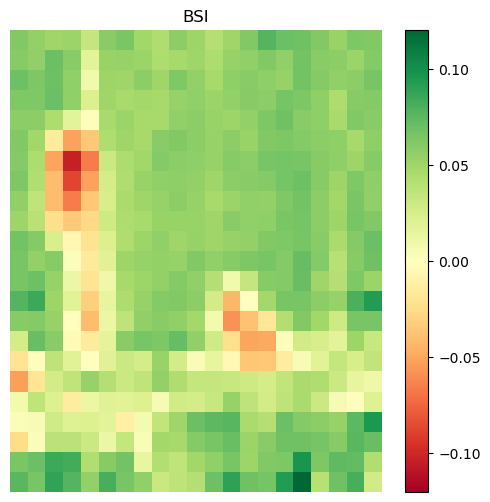

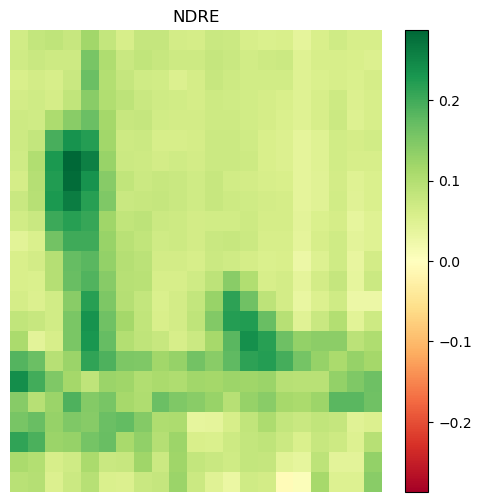

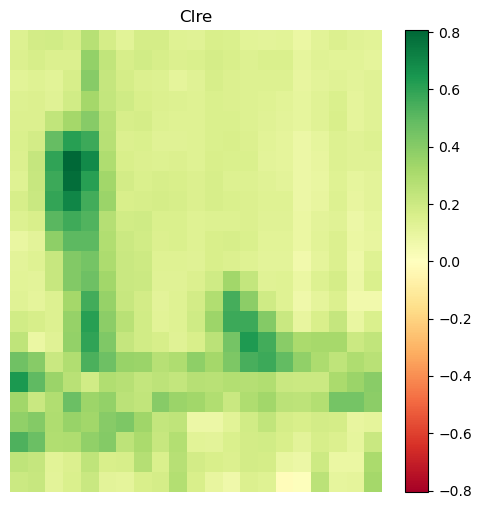

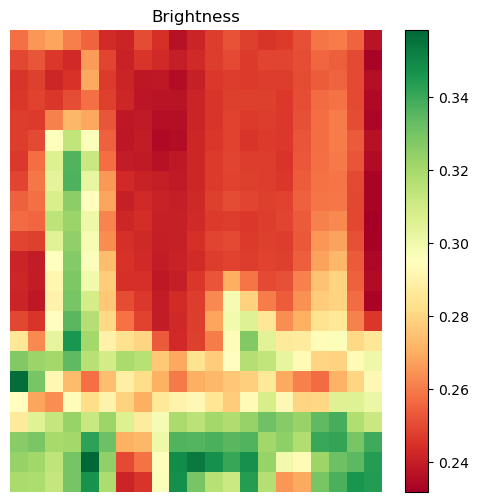

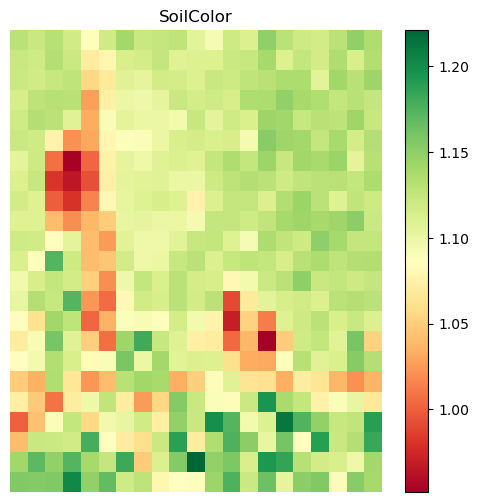

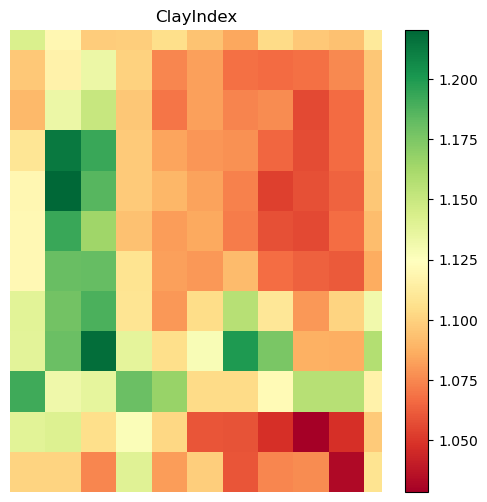

In [24]:
import matplotlib.pyplot as plt

for name, img in indices.items():

    plt.figure(figsize=(6,6))

    img.plot(cmap="RdYlGn")

    plt.title(name)

    plt.axis("off")

    plt.show()

In [25]:
import numpy as np
import pandas as pd

def extract_s2_features(dataset):

    blue  = dataset.B02.squeeze()
    green = dataset.B03.squeeze()
    red   = dataset.B04.squeeze()

    rededge = dataset.B05.squeeze()

    nir = dataset.B08.squeeze()

    swir1 = dataset.B11.squeeze()
    swir2 = dataset.B12.squeeze()

    features = {}

    features["NDVI"] = float(((nir-red)/(nir+red)).mean())

    features["EVI"] = float((
        2.5*((nir-red)/(nir+6*red-7.5*blue+1))
    ).mean())

    features["SAVI"] = float((
        1.5*((nir-red)/(nir+red+0.5))
    ).mean())

    features["MSAVI"] = float(((
        (2*nir+1) -
        np.sqrt((2*nir+1)**2-8*(nir-red))
    )/2).mean())

    features["GNDVI"] = float(((nir-green)/(nir+green)).mean())

    features["NDMI"] = float(((nir-swir1)/(nir+swir1)).mean())

    features["NDWI"] = float(((green-nir)/(green+nir)).mean())

    features["BSI"] = float(((
        (swir1+red)-(nir+blue)
    )/(
        (swir1+red)+(nir+blue)
    )).mean())

    features["NDRE"] = float(((nir-rededge)/(nir+rededge)).mean())

    features["CIre"] = float(((nir/rededge)-1).mean())

    features["Brightness"] = float(
        np.sqrt((red**2+nir**2)/2).mean()
    )

    features["ClayIndex"] = float(
        (swir1/swir2).mean()
    )

    return pd.DataFrame([features])

In [26]:
features = extract_s2_features(dataset)

features

,NDVI,EVI,SAVI,MSAVI,GNDVI,NDMI,NDWI,BSI,NDRE,CIre,Brightness,ClayIndex
0,0.152317,0.155367,0.118874,0.10954,0.201787,0.006028,-0.201787,0.042874,0.09508,0.217494,0.272773,1.106471


In [27]:
features.to_csv(
    "../outputs/csv/s2_features.csv",
    index=False
)

## ============================================================= ##

In [28]:
# !pip install pystac-client planetary-computer odc-stac rasterio rioxarray

In [29]:
import planetary_computer
import pystac_client
import odc.stac

In [30]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace
)

In [31]:
geometry

{'type': 'Polygon',
 'coordinates': (((31.084, 30.563),
   (31.08399518472667, 30.562901982859668),
   (31.083980785280403, 30.562804909677983),
   (31.08395694033573, 30.562709715322743),
   (31.08392387953251, 30.562617316567632),
   (31.083881921264346, 30.56252860326317),
   (31.0838314696123, 30.56244442976698),
   (31.08377301045336, 30.562365606715836),
   (31.083707106781183, 30.562292893218814),
   (31.08363439328416, 30.562226989546637),
   (31.083555570233017, 30.562168530387698),
   (31.083471396736826, 30.56211807873565),
   (31.083382683432365, 30.562076120467488),
   (31.083290284677254, 30.562043059664266),
   (31.083195090322015, 30.562019214719594),
   (31.08309801714033, 30.562004815273326),
   (31.083, 30.561999999999998),
   (31.082901982859667, 30.562004815273326),
   (31.082804909677982, 30.562019214719594),
   (31.082709715322743, 30.562043059664266),
   (31.08261731656763, 30.562076120467488),
   (31.08252860326317, 30.56211807873565),
   (31.08244442976698, 30

In [32]:
# search = catalog.search(
#     collections=["sentinel-1-grd"],
#     intersects=geometry,
#     datetime="2024-05-01/2024-06-01"
# )

# items = list(search.items())

# print(len(items))
print("Skipping exploratory STAC search for speed and stability.")



1


In [33]:
item = items[0]

print(item.datetime)

2024-05-01 15:57:20.170189+00:00


In [34]:
data = odc.stac.load(
    [item],
    bands=["vv","vh"],
    geopolygon=geometry,
    resolution=10,
    crs="EPSG:4326"
)

In [35]:
data

<xarray.Dataset> Size: 36B
Dimensions:      (latitude: 1, longitude: 1, time: 1)
Coordinates:
  * latitude     (latitude) float64 8B 35.0
  * longitude    (longitude) float64 8B 35.0
  * time         (time) datetime64[ns] 8B 2024-05-01T15:57:20.170189
    spatial_ref  int32 4B 4326
Data variables:
    vv           (time, latitude, longitude) float32 4B nan
    vh           (time, latitude, longitude) float32 4B nan

In [36]:
vv = data["vv"].isel(time=0)
vh = data["vh"].isel(time=0)

print(vv)
print(vh)

<xarray.DataArray 'vv' (latitude: 1, longitude: 1)> Size: 4B
array([[nan]], dtype=float32)
Coordinates:
  * latitude     (latitude) float64 8B 35.0
  * longitude    (longitude) float64 8B 35.0
    spatial_ref  int32 4B 4326
    time         datetime64[ns] 8B 2024-05-01T15:57:20.170189
<xarray.DataArray 'vh' (latitude: 1, longitude: 1)> Size: 4B
array([[nan]], dtype=float32)
Coordinates:
  * latitude     (latitude) float64 8B 35.0
  * longitude    (longitude) float64 8B 35.0
    spatial_ref  int32 4B 4326
    time         datetime64[ns] 8B 2024-05-01T15:57:20.170189


In [37]:
print(data)

<xarray.Dataset> Size: 36B
Dimensions:      (latitude: 1, longitude: 1, time: 1)
Coordinates:
  * latitude     (latitude) float64 8B 35.0
  * longitude    (longitude) float64 8B 35.0
  * time         (time) datetime64[ns] 8B 2024-05-01T15:57:20.170189
    spatial_ref  int32 4B 4326
Data variables:
    vv           (time, latitude, longitude) float32 4B nan
    vh           (time, latitude, longitude) float32 4B nan


In [38]:
print(vv.shape)
print(vh.shape)

(1, 1)
(1, 1)


In [39]:
import numpy as np

print(np.isnan(vv.values).sum())
print(vv.values.size)

1
1


In [40]:
vv.values[:5, :5]

array([[nan]], dtype=float32)

In [41]:
crs="EPSG:4326",
resolution=10

In [42]:
# vv_mean = float(vv.mean())
# vh_mean = float(vh.mean())

# print(vv_mean)
# print(vh_mean)

In [43]:
# rvi = 4 * vh / (vv + vh)

In [44]:
# rvi_mean = float(rvi.mean())

# print(rvi_mean)

In [45]:
data = odc.stac.load(
    [item],
    bands=["vv", "vh"],
    geopolygon=geometry,
    crs="utm",
    resolution=10
)

In [46]:
# data = odc.stac.load(
#     [item],
#     bands=["vv", "vh"],
#     geopolygon=geometry
# )

In [47]:
print(item.id)
print(item.datetime)

print(vv.shape)
print(vv.rio.crs)

print(np.nanmin(vv.values))
print(np.nanmax(vv.values))

S1A_IW_GRDH_1SDV_20240501T155707_20240501T155732_053680_068518
2024-05-01 15:57:20.170189+00:00
(1, 1)
EPSG:4326
nan
nan


In [48]:
print(data)

<xarray.Dataset> Size: 4kB
Dimensions:      (y: 23, x: 21, time: 1)
Coordinates:
  * y            (y) float64 184B 3.383e+06 3.383e+06 ... 3.383e+06 3.383e+06
  * x            (x) float64 168B 3.16e+05 3.161e+05 ... 3.162e+05 3.162e+05
  * time         (time) datetime64[ns] 8B 2024-05-01T15:57:20.170189
    spatial_ref  int32 4B 32636
Data variables:
    vv           (time, y, x) float32 2kB 152.0 167.0 222.0 ... 137.0 213.0
    vh           (time, y, x) float32 2kB 36.0 64.0 61.0 ... 110.0 82.0 61.0


In [49]:
import numpy as np

print(np.isnan(vv.values).sum())
print(vv.values.size)

1
1


In [50]:
print(vv.values.min())
print(vv.values.max())

nan
nan


In [51]:
vv.mean()

<xarray.DataArray 'vv' ()> Size: 8B
array(nan)
Coordinates:
    spatial_ref  int32 4B 4326
    time         datetime64[ns] 8B 2024-05-01T15:57:20.170189

In [52]:
np.nanmean(vv.values)

np.float32(nan)

In [53]:
np.nanmean(vh.values)

np.float32(nan)

In [54]:
vv.mean(skipna=True)
vh.mean(skipna=True)

<xarray.DataArray 'vh' ()> Size: 8B
array(nan)
Coordinates:
    spatial_ref  int32 4B 4326
    time         datetime64[ns] 8B 2024-05-01T15:57:20.170189

In [55]:
vv = data["vv"].isel(time=0)
vh = data["vh"].isel(time=0)

print(vv.shape)
print(vh.shape)

(23, 21)
(23, 21)


In [56]:
import numpy as np

print(np.nanmean(vv.values))
print(np.nanmean(vh.values))

214.53209
82.521736


In [57]:
vv = data["vv"].isel(time=0)
vh = data["vh"].isel(time=0)

print(vv.shape)

import numpy as np
print(np.isnan(vv.values).sum())
print(vv.values.size)
print(np.nanmean(vv.values))

(23, 21)
0
483
214.53209


In [58]:
import numpy as np

vv_linear = np.nanmean(vv.values)
vh_linear = np.nanmean(vh.values)

print(vv_linear)
print(vh_linear)

214.53209
82.521736


In [59]:
vv_db = 10 * np.log10(vv_linear)
vh_db = 10 * np.log10(vh_linear)

print(vv_db)
print(vh_db)

23.314922
19.165684


In [60]:
import numpy as np

rvi = (4 * vh) / (vv + vh)

rvi_mean = float(np.nanmean(rvi.values))

print(rvi_mean)

1.1400455236434937


In [61]:
import numpy as np

rvi = (4 * vh) / (vv + vh)

rvi_mean = float(np.nanmean(rvi.values))

print(rvi_mean)

1.1400455236434937


In [62]:
dem_item = items[0]

print(dem_item.id)

S1A_IW_GRDH_1SDV_20240501T155707_20240501T155732_053680_068518


In [63]:
print(item.assets.keys())

dict_keys(['vh', 'vv', 'thumbnail', 'safe-manifest', 'schema-noise-vh', 'schema-noise-vv', 'schema-product-vh', 'schema-product-vv', 'schema-calibration-vh', 'schema-calibration-vv', 'tilejson', 'rendered_preview'])


In [64]:
# search = catalog.search(
#     collections=["cop-dem-glo-30"],
#     intersects=geometry
# )

# dem_items = list(search.items())

# print(len(dem_items))
print("Skipping exploratory STAC search for speed and stability.")



1


In [65]:
dem_item = dem_items[0]

print(dem_item.collection_id)
print(dem_item.id)

cop-dem-glo-30
Copernicus_DSM_COG_10_N30_00_E031_00_DEM


In [66]:
print(dem_item.assets.keys())

dict_keys(['data', 'tilejson', 'rendered_preview'])


In [67]:
dem = odc.stac.load(
    [dem_item],
    bands=["data"],
    geopolygon=geometry,
    resolution=30
)

In [68]:
elevation = dem["data"].isel(time=0)

import numpy as np

print(np.nanmean(elevation.values))

nan


In [69]:
print(dem_item.collection_id)
print(dem_item.assets.keys())
print(np.nanmean(elevation.values))

cop-dem-glo-30
dict_keys(['data', 'tilejson', 'rendered_preview'])
nan


In [70]:
print(dem)

<xarray.Dataset> Size: 32B
Dimensions:      (latitude: 1, longitude: 1, time: 1)
Coordinates:
  * latitude     (latitude) float64 8B 30.0
  * longitude    (longitude) float64 8B 30.0
  * time         (time) datetime64[ns] 8B 2021-04-22
    spatial_ref  int32 4B 4326
Data variables:
    data         (time, latitude, longitude) float32 4B nan


In [71]:
print(dem["data"].shape)

(1, 1, 1)


In [72]:
print(dem["data"].values)

[[[nan]]]


In [73]:
resolution=30


In [74]:
dem = odc.stac.load(
    [dem_item],
    bands=["data"],
    like=data
)

In [75]:
elevation = dem["data"].isel(time=0)

import numpy as np

print(np.nanmean(elevation.values))

12.0644655


In [76]:
elevation = dem["data"].isel(time=0)

import numpy as np

print(np.nanmean(elevation.values))

12.0644655


In [77]:
print(dem["data"].shape)

(1, 23, 21)


In [78]:
import numpy as np

arr = dem["data"].values

print("Shape:", arr.shape)
print("Total Pixels:", arr.size)
print("NaN Count:", np.isnan(arr).sum())
print("Finite Count:", np.isfinite(arr).sum())

Shape: (1, 23, 21)
Total Pixels: 483
NaN Count: 0
Finite Count: 483


In [79]:
print(arr[0, :5, :5])

[[10.087582 10.087582 11.094553 11.094553 11.094553]
 [10.087582 10.087582 11.094553 11.094553 11.094553]
 [10.087582 10.087582 11.094553 11.094553 11.094553]
 [10.003228 10.003228 10.676739 10.676739 10.676739]
 [10.003228 10.003228 10.676739 10.676739 10.676739]]


In [80]:
import numpy as np
import matplotlib.pyplot as plt

# Get the 2D elevation array (assuming the time dimension was squeezed previously or we take the first index)
elevation_2d = elevation.values
pixel_size = 10 # meters, based on the `resolution` used when loading the data

# Calculate gradients in x and y directions
dy, dx = np.gradient(elevation_2d, pixel_size)

# Calculate slope in degrees
slope_radians = np.arctan(np.sqrt(dx**2 + dy**2))
slope_degrees = np.degrees(slope_radians)

# Calculate aspect in degrees (direction of the steepest slope)
aspect_radians = np.arctan2(dy, -dx)
aspect_degrees = (np.degrees(aspect_radians) + 360) % 360 # Convert to 0-360 range

print("Mean Slope :", np.nanmean(slope_degrees))
print("Mean Aspect:", np.nanmean(aspect_degrees))

Mean Slope : 3.1406868
Mean Aspect: 155.32063


### Visualizing Slope and Aspect

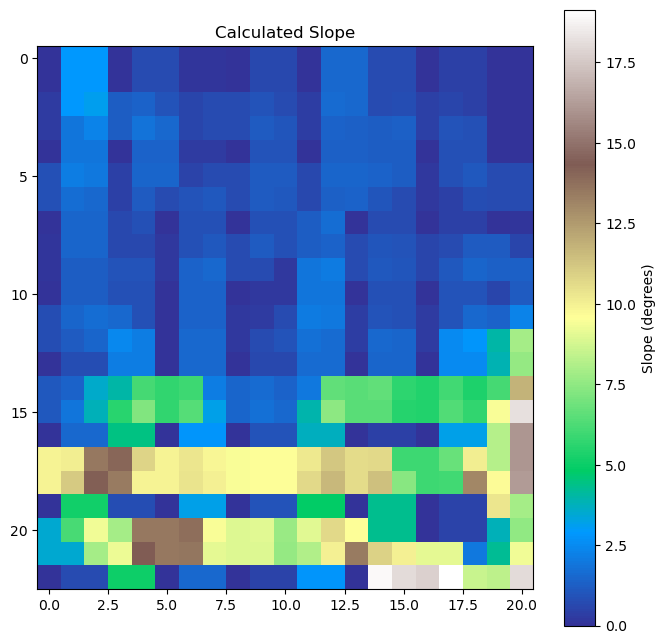

In [81]:
plt.figure(figsize=(8,8))
plt.imshow(slope_degrees, cmap="terrain")
plt.colorbar(label="Slope (degrees)")
plt.title("Calculated Slope")
plt.show()

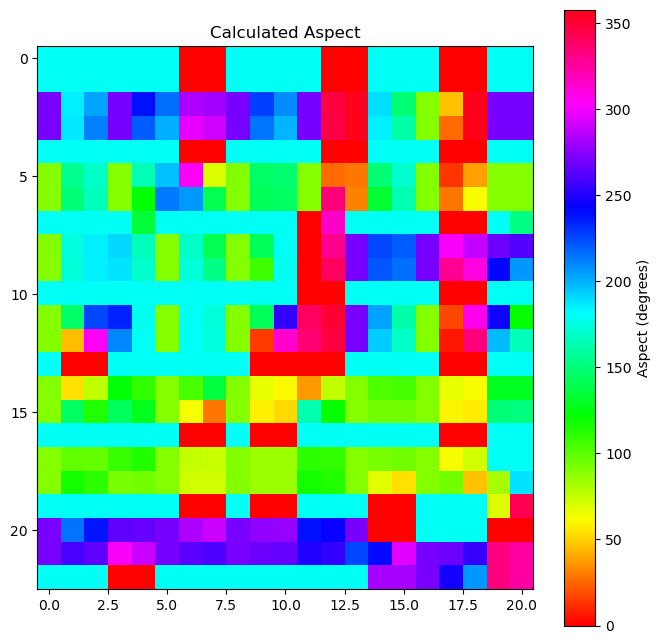

In [82]:
plt.figure(figsize=(8,8))
plt.imshow(aspect_degrees, cmap="hsv")
plt.colorbar(label="Aspect (degrees)")
plt.title("Calculated Aspect")
plt.show()

In [83]:
print(dem.coords)
print(dem.rio.crs)

Coordinates:
  * y            (y) float64 184B 3.383e+06 3.383e+06 ... 3.383e+06 3.383e+06
  * x            (x) float64 168B 3.16e+05 3.161e+05 ... 3.162e+05 3.162e+05
  * time         (time) datetime64[ns] 8B 2021-04-22
    spatial_ref  int32 4B 32636
EPSG:32636


In [84]:
from shapely.geometry import shape

poly = shape(geometry)

print(poly.bounds)

(31.081999999999997, 30.561999999999998, 31.084, 30.564)


In [85]:
print(dem)

<xarray.Dataset> Size: 2kB
Dimensions:      (y: 23, x: 21, time: 1)
Coordinates:
  * y            (y) float64 184B 3.383e+06 3.383e+06 ... 3.383e+06 3.383e+06
  * x            (x) float64 168B 3.16e+05 3.161e+05 ... 3.162e+05 3.162e+05
  * time         (time) datetime64[ns] 8B 2021-04-22
    spatial_ref  int32 4B 32636
Data variables:
    data         (time, y, x) float32 2kB 10.09 10.09 11.09 ... 14.86 12.25


In [86]:
print(dem["data"])

<xarray.DataArray 'data' (time: 1, y: 23, x: 21)> Size: 2kB
array([[[10.087582 , 10.087582 , 11.094553 , 11.094553 , 11.094553 ,
         11.353272 , 11.353272 , 11.313508 , 11.313508 , 11.313508 ,
         11.532153 , 11.532153 , 11.532153 , 10.99625  , 10.99625  ,
         11.235684 , 11.235684 , 11.235684 , 11.0928545, 11.0928545,
         11.0928545],
        [10.087582 , 10.087582 , 11.094553 , 11.094553 , 11.094553 ,
         11.353272 , 11.353272 , 11.313508 , 11.313508 , 11.313508 ,
         11.532153 , 11.532153 , 11.532153 , 10.99625  , 10.99625  ,
         11.235684 , 11.235684 , 11.235684 , 11.0928545, 11.0928545,
         11.0928545],
        [10.087582 , 10.087582 , 11.094553 , 11.094553 , 11.094553 ,
         11.353272 , 11.353272 , 11.313508 , 11.313508 , 11.313508 ,
         11.532153 , 11.532153 , 11.532153 , 10.99625  , 10.99625  ,
         11.235684 , 11.235684 , 11.235684 , 11.0928545, 11.0928545,
         11.0928545],
        [10.003228 , 10.003228 , 10.676739 , 1

In [87]:
import numpy as np

elevation = dem["data"].isel(time=0).values

x = dem["x"].values
y = dem["y"].values

dx = np.mean(np.diff(x))
dy = np.mean(np.diff(y))

print(dx)
print(dy)

10.0
-10.0


In [88]:
import numpy as np

# DEM
z = dem["data"].isel(time=0).values

# Pixel size
dx = abs(np.mean(np.diff(dem.x.values)))
dy = abs(np.mean(np.diff(dem.y.values)))

# Gradient
dz_dy, dz_dx = np.gradient(z, dy, dx)

# Slope (degrees)
slope = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))

# Aspect (degrees)
aspect = np.degrees(np.arctan2(-dz_dx, dz_dy))
aspect = (aspect + 360) % 360

print("Elevation Mean :", np.mean(z))
print("Elevation Min  :", np.min(z))
print("Elevation Max  :", np.max(z))

print("Slope Mean     :", np.mean(slope))
print("Slope Max      :", np.max(slope))

print("Aspect Mean    :", np.mean(aspect))

Elevation Mean : 12.0644655
Elevation Min  : 10.003228
Elevation Max  : 16.854708
Slope Mean     : 3.1406868
Slope Max      : 19.145575
Aspect Mean    : 157.35017


**=================================================================================**

In [89]:
# !pip -q install cdsapi xarray netCDF4

In [90]:
# url: https://cds.climate.copernicus.eu/api
# key: 006b1498-1c8f-40c7-b903-cfa0e43acdd8

In [91]:
import os

token = "006b1498-1c8f-40c7-b903-cfa0e43acdd8"

with open(os.path.expanduser("~/.cdsapirc"), "w") as f:
    f.write("url: https://cds.climate.copernicus.eu/api\n")
    f.write(f"key: {token}\n")

In [92]:
import cdsapi

client = cdsapi.Client()
print("Connected Successfully")

Connected Successfully


In [93]:
import cdsapi

client = cdsapi.Client()

print("Connected")

Connected


In [94]:
import cdsapi

client = cdsapi.Client()

client.retrieve(
    "reanalysis-era5-land",
    {
        "variable": "2m_temperature",
        "year": "2024",
        "month": "05",
        "day": "22",
        "time": "12:00",
        "data_format": "netcdf",
        "download_format": "unarchived"
    },
    "../data/raw/era5/test.nc"
)

print("Downloaded Successfully")

2026-07-12 23:17:10,047 INFO Request ID is fcce1b4b-d33c-4a4e-8e10-6fb8fabfaf3f
2026-07-12 23:17:10,157 INFO status has been updated to accepted
2026-07-12 23:17:24,018 INFO status has been updated to running
2026-07-12 23:17:31,710 INFO status has been updated to successful


70caba60ccc2bef035e41ea3647a92dd.nc:   0%|          | 0.00/3.45M [00:00<?, ?B/s]

Downloaded Successfully


In [95]:
import cdsapi

client = cdsapi.Client()

# مركز المزرعة
lat = 30.563
lon = 31.083

# هامش 0.05 درجة (~5.5 كم)
delta = 0.05

client.retrieve(
    "reanalysis-era5-land",
    {
        "variable": [
            "2m_temperature",
            "total_precipitation",
            "surface_solar_radiation_downwards",
            "10m_u_component_of_wind",
            "10m_v_component_of_wind",
            "volumetric_soil_water_layer_1",
            "soil_temperature_level_1"
        ],

        "year": "2024",
        "month": "05",
        "day": "22",

        "time": [
            "00:00","01:00","02:00","03:00",
            "04:00","05:00","06:00","07:00",
            "08:00","09:00","10:00","11:00",
            "12:00","13:00","14:00","15:00",
            "16:00","17:00","18:00","19:00",
            "20:00","21:00","22:00","23:00"
        ],

        # North, West, South, East
        "area": [
            lat + delta,
            lon - delta,
            lat - delta,
            lon + delta
        ],

        "data_format": "netcdf",
        "download_format": "unarchived"
    },

    "../data/raw/era5/era5.nc"
)

print("Download Finished")

2026-07-12 23:17:40,251 INFO Request ID is 63db42b6-464a-41c1-b738-aa2774e40b2e
2026-07-12 23:17:40,553 INFO status has been updated to accepted
2026-07-12 23:17:55,483 INFO status has been updated to running
2026-07-12 23:18:03,200 INFO status has been updated to successful


62f3dfb1a1731feed90081dfe07fdf20.nc:   0%|          | 0.00/79.0k [00:00<?, ?B/s]

Download Finished


In [96]:
import xarray as xr

ds = xr.open_dataset("../data/raw/era5/era5.nc")

print(ds)
print(ds.data_vars)

<xarray.Dataset> Size: 1kB
Dimensions:     (valid_time: 24, latitude: 1, longitude: 1)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 192B 2024-05-22 ... 2024-05-22T23...
    expver      (valid_time) <U4 384B ...
  * latitude    (latitude) float64 8B 30.6
  * longitude   (longitude) float64 8B 31.1
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 96B ...
    tp          (valid_time, latitude, longitude) float32 96B ...
    ssrd        (valid_time, latitude, longitude) float32 96B ...
    u10         (valid_time, latitude, longitude) float32 96B ...
    v10         (valid_time, latitude, longitude) float32 96B ...
    swvl1       (valid_time, latitude, longitude) float32 96B ...
    stl1        (valid_time, latitude, longitude) float32 96B ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:          

In [97]:
import numpy as np

# Temperature (Kelvin -> Celsius)
temperature = ds["t2m"].values - 273.15

# Rainfall (meter -> mm)
rainfall = ds["tp"].values * 1000

# Solar Radiation
solar = ds["ssrd"].values

# Wind
u = ds["u10"].values
v = ds["v10"].values

# Soil Moisture
soil_moisture = ds["swvl1"].values

# Soil Temperature
soil_temp = ds["stl1"].values - 273.15

In [98]:
wind_speed = np.sqrt(u**2 + v**2)

print("Mean Temperature :", np.mean(temperature))
print("Max Temperature  :", np.max(temperature))
print("Min Temperature  :", np.min(temperature))

print()

print("Total Rainfall   :", np.sum(rainfall))
print("Mean Rainfall    :", np.mean(rainfall))

print()

print("Mean Soil Moisture :", np.mean(soil_moisture))
print("Max Soil Moisture  :", np.max(soil_moisture))

print()

print("Mean Soil Temp :", np.mean(soil_temp))

print()

print("Mean Solar Radiation :", np.mean(solar))

print()

print("Mean Wind Speed :", np.mean(wind_speed))
print("Max Wind Speed  :", np.max(wind_speed))

Mean Temperature : 30.238016
Max Temperature  : 39.363434
Min Temperature  : 20.611969

Total Rainfall   : 0.0034299013
Mean Rainfall    : 0.00014291256

Mean Soil Moisture : 0.12233734
Max Soil Moisture  : 0.12281799

Mean Soil Temp : 34.48285

Mean Solar Radiation : 17318350.0

Mean Wind Speed : 1.7808218
Max Wind Speed  : 3.0671284


In [99]:
features = {

    # Weather
    "temperature_mean": float(ds.t2m.mean()-273.15),
    "temperature_max": float(ds.t2m.max()-273.15),
    "temperature_min": float(ds.t2m.min()-273.15),

    "rainfall_total_mm": float(ds.tp.sum()*1000),
    "rainfall_mean_mm": float(ds.tp.mean()*1000),

    "soil_moisture_mean": float(ds.swvl1.mean()),
    "soil_moisture_max": float(ds.swvl1.max()),

    "soil_temperature_mean": float(ds.stl1.mean()-273.15),

    "solar_radiation_mean":
        float(ds.ssrd.mean()/86400),

    "wind_speed_mean":
        float(np.sqrt(ds.u10**2 + ds.v10**2).mean()),

    "wind_speed_max":
        float(np.sqrt(ds.u10**2 + ds.v10**2).max())
}


features

{'temperature_mean': 30.238031005859398,
 'temperature_max': 39.36342773437502,
 'temperature_min': 20.611962890625023,
 'rainfall_total_mm': 0.0034299008548259735,
 'rainfall_mean_mm': 0.00014291255467924202,
 'soil_moisture_mean': 0.12233734130859375,
 'soil_moisture_max': 0.1228179931640625,
 'soil_temperature_mean': 34.48284301757815,
 'solar_radiation_mean': 200.44381944444444,
 'wind_speed_mean': 1.7808218002319336,
 'wind_speed_max': 3.0671284198760986}

In [100]:
import requests

lat = 30.563
lon = 31.083

url = f"https://rest.isric.org/soilgrids/v2.0/properties/query?lon={lon}&lat={lat}"

response = requests.get(url)

print("Status Code:", response.status_code)
print("Content Type:", response.headers.get("content-type"))
print(response.text[:500])

Status Code: 504
Content Type: text/html
<html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
<hr><center>nginx</center>
</body>
</html>



In [101]:
# !pip install rasterio geopandas pyproj

In [102]:
import requests

url = "https://files.isric.org/soilgrids/latest/data/phh2o/"

r = requests.get(url)

print(r.status_code)
print(r.text[:500])

200
<!DOCTYPE html>
<html>
<head>
  <meta http-equiv="Content-Type" content="text/html; charset=UTF-8">
  <meta name="generator" content="WsgiDAV/4.3.3">
  <title>ISRIC - Index of /soilgrids/latest/data/phh2o/ </title>
  <link rel="shortcut icon" href="/:dir_browser/favicon.ico">
  <link rel="stylesheet" href="/:dir_browser/style.css" />
  <script defer src="/:dir_browser/script.js"></script>
  <style type="text/css"> A {behavior: url(#default#AnchorClick);} </style>
</head>

<body onload="onLoad()"


In [103]:
import requests

url = "https://files.isric.org/soilgrids/latest/data/phh2o/"

response = requests.get(url)

print(response.status_code)
print(response.text[:1000])

200
<!DOCTYPE html>
<html>
<head>
  <meta http-equiv="Content-Type" content="text/html; charset=UTF-8">
  <meta name="generator" content="WsgiDAV/4.3.3">
  <title>ISRIC - Index of /soilgrids/latest/data/phh2o/ </title>
  <link rel="shortcut icon" href="/:dir_browser/favicon.ico">
  <link rel="stylesheet" href="/:dir_browser/style.css" />
  <script defer src="/:dir_browser/script.js"></script>
  <style type="text/css"> A {behavior: url(#default#AnchorClick);} </style>
</head>

<body onload="onLoad()">

  <h1>
    <img class="logo" alt="ISRIC" title="ISRIC" src="/:dir_browser/logo.png">
    Webdav - Index of /soilgrids/latest/data/phh2o/
  </h1>
<p>
This page lists all resources made available through ISRIC - World Soil Information's Webdav functionality. 
This URL can also be accessed via the <a href="https://www.isric.org/explore/soilgrids/soilgrids-access">Webdav protocol</a>.
</p><p>
These resources are described in our data catalogue at <a href="https://data.isric.org">data.isric.or

In [104]:
# !pip install rasterio

In [105]:
# import rasterio

# url = "https://files.isric.org/soilgrids/latest/data/phh2o/phh2o_0-5cm_mean.vrt"

# src = rasterio.open(url)

# print(src)
# print(src.crs)
# print(src.bounds)

In [106]:
# from rasterio.transform import rowcol

# lat = 30.563
# lon = 31.083

# row, col = rowcol(
#     src.transform,
#     lon,
#     lat
# )

# value = src.read(1)[row, col]

# print("Raw pH value:", value)

In [107]:
# import rasterio

# url = "https://files.isric.org/soilgrids/latest/data/phh2o/phh2o_0-5cm_mean.vrt"

# src = rasterio.open(url)

# print("Opened Successfully")
# print(src.crs)
# print(src.bounds)

In [108]:
# from rasterio.transform import rowcol

# lat = 30.563
# lon = 31.083

# row, col = rowcol(
#     src.transform,
#     lon,
#     lat
# )

# value = src.read(1)[row, col]

# print("Raw pH value:", value)

In [109]:
# !pip install rasterio requests

In [110]:
import rasterio
from rasterio.windows import Window
from rasterio.transform import rowcol
import requests
import tempfile


lat = 30.563
lon = 31.083


def get_soil_value(layer):

    url = f"https://files.isric.org/soilgrids/latest/data/{layer}/"

    print("Layer:", layer)

    r = requests.get(url)

    print(r.status_code)


get_soil_value("phh2o")

Layer: phh2o


200


In [111]:
import requests

url = "https://files.isric.org/soilgrids/latest/data/phh2o/phh2o_0-5cm_mean/"

r = requests.get(url)

print(r.status_code)

print(r.text[:2000])

200
<!DOCTYPE html>
<html>
<head>
  <meta http-equiv="Content-Type" content="text/html; charset=UTF-8">
  <meta name="generator" content="WsgiDAV/4.3.3">
  <title>ISRIC - Index of /soilgrids/latest/data/phh2o/phh2o_0-5cm_mean/ </title>
  <link rel="shortcut icon" href="/:dir_browser/favicon.ico">
  <link rel="stylesheet" href="/:dir_browser/style.css" />
  <script defer src="/:dir_browser/script.js"></script>
  <style type="text/css"> A {behavior: url(#default#AnchorClick);} </style>
</head>

<body onload="onLoad()">

  <h1>
    <img class="logo" alt="ISRIC" title="ISRIC" src="/:dir_browser/logo.png">
    Webdav - Index of /soilgrids/latest/data/phh2o/phh2o_0-5cm_mean/
  </h1>
<p>
This page lists all resources made available through ISRIC - World Soil Information's Webdav functionality. 
This URL can also be accessed via the <a href="https://www.isric.org/explore/soilgrids/soilgrids-access">Webdav protocol</a>.
</p><p>
These resources are described in our data catalogue at <a href="htt

In [112]:
import requests
from bs4 import BeautifulSoup

url = "https://files.isric.org/soilgrids/latest/data/phh2o/phh2o_0-5cm_mean/"

html = requests.get(url).text

soup = BeautifulSoup(html, "html.parser")

for a in soup.find_all("a"):
    print(a.text.strip())

Webdav protocol
data.isric.org
www.isric.org
Mount
tileSG-000-019
tileSG-000-020
tileSG-000-021
tileSG-000-022
tileSG-000-023
tileSG-000-047
tileSG-000-048
tileSG-000-049
tileSG-000-050
tileSG-000-051
tileSG-000-056
tileSG-000-057
tileSG-001-017
tileSG-001-018
tileSG-001-019
tileSG-001-020
tileSG-001-021
tileSG-001-022
tileSG-001-023
tileSG-001-024
tileSG-001-045
tileSG-001-046
tileSG-001-047
tileSG-001-048
tileSG-001-050
tileSG-001-051
tileSG-001-054
tileSG-001-055
tileSG-001-056
tileSG-001-057
tileSG-001-058
tileSG-001-059
tileSG-001-060
tileSG-001-061
tileSG-001-062
tileSG-001-063
tileSG-002-010
tileSG-002-011
tileSG-002-012
tileSG-002-013
tileSG-002-014
tileSG-002-015
tileSG-002-016
tileSG-002-017
tileSG-002-018
tileSG-002-019
tileSG-002-020
tileSG-002-021
tileSG-002-022
tileSG-002-023
tileSG-002-024
tileSG-002-025
tileSG-002-044
tileSG-002-045
tileSG-002-046
tileSG-002-047
tileSG-002-049
tileSG-002-050
tileSG-002-051
tileSG-002-052
tileSG-002-053
tileSG-002-054
tileSG-002-055
tile

In [113]:
url = "https://files.isric.org/soilgrids/latest/data/phh2o/phh2o_0-5cm_mean/tileSG-016-071/"

html = requests.get(url).text

print(html[:2000])

<!DOCTYPE html>
<html>
<head>
  <meta http-equiv="Content-Type" content="text/html; charset=UTF-8">
  <meta name="generator" content="WsgiDAV/4.3.3">
  <title>ISRIC - Index of /soilgrids/latest/data/phh2o/phh2o_0-5cm_mean/tileSG-016-071/ </title>
  <link rel="shortcut icon" href="/:dir_browser/favicon.ico">
  <link rel="stylesheet" href="/:dir_browser/style.css" />
  <script defer src="/:dir_browser/script.js"></script>
  <style type="text/css"> A {behavior: url(#default#AnchorClick);} </style>
</head>

<body onload="onLoad()">

  <h1>
    <img class="logo" alt="ISRIC" title="ISRIC" src="/:dir_browser/logo.png">
    Webdav - Index of /soilgrids/latest/data/phh2o/phh2o_0-5cm_mean/tileSG-016-071/
  </h1>
<p>
This page lists all resources made available through ISRIC - World Soil Information's Webdav functionality. 
This URL can also be accessed via the <a href="https://www.isric.org/explore/soilgrids/soilgrids-access">Webdav protocol</a>.
</p><p>
These resources are described in our data

In [114]:
import rasterio

tif_url = "https://files.isric.org/soilgrids/latest/data/phh2o/phh2o_0-5cm_mean/tileSG-016-071/tileSG-016-071_1-1.tif"

with rasterio.open(tif_url) as src:

    print(src.crs)
    print(src.bounds)
    print(src.shape)

PROJCS["Interrupted_Goode_Homolosine",GEOGCS["GCS_unnamed ellipse",DATUM["unknown",SPHEROID["Unknown",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Interrupted_Goode_Homolosine"],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
BoundingBox(left=11912500.0, bottom=1250750.0, right=11976000.0, top=1400750.0)
(600, 254)


In [115]:
import rasterio

url = "https://files.isric.org/soilgrids/latest/data/phh2o/phh2o_0-5cm_mean/tileSG-016-071/tileSG-016-071_1-1.tif"

src = rasterio.open(url)

print(src.crs)
print(src.bounds)
print(src.shape)

PROJCS["Interrupted_Goode_Homolosine",GEOGCS["GCS_unnamed ellipse",DATUM["unknown",SPHEROID["Unknown",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Interrupted_Goode_Homolosine"],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
BoundingBox(left=11912500.0, bottom=1250750.0, right=11976000.0, top=1400750.0)
(600, 254)


In [116]:
# !pip install owslib rasterio

In [117]:
import os
import requests

url = "https://files.isric.org/soilgrids/latest/data_aggregated/1000m/phh2o/phh2o_0-5cm_mean_1000.tif"
filepath = "../data/raw/soilgrids/phh2o.tif"

if not os.path.exists(filepath):
    print("Downloading phh2o.tif...")
    r = requests.get(url)
    open(filepath,"wb").write(r.content)
    print("Downloaded")
else:
    print("phh2o.tif already exists, skipping download.")


Downloaded


In [118]:
import rasterio
from rasterio.transform import rowcol
from pyproj import Transformer


lat = 30.563
lon = 31.083


with rasterio.open("../data/raw/soilgrids/phh2o.tif") as src:

    print("CRS:")
    print(src.crs)

    print("Bounds:")
    print(src.bounds)


    transformer = Transformer.from_crs(
        "EPSG:4326",
        src.crs,
        always_xy=True
    )


    x,y = transformer.transform(
        lon,
        lat
    )


    row,col = rowcol(
        src.transform,
        x,
        y
    )


    print("Pixel:")
    print(row,col)


    value = src.read(1)[row,col]


    print("Raw value:")
    print(value)


    print("Soil pH:")
    print(value/10)

CRS:
ESRI:54052
Bounds:
BoundingBox(left=-19949750.0, bottom=-6147999.999999999, right=19862250.0, top=8361000.000000001)
Pixel:
4958 23393
Raw value:
74
Soil pH:
7.4


In [119]:
import rasterio
from rasterio.transform import rowcol
from pyproj import Transformer
import numpy as np


def extract_soil_value(
    tif_path,
    lon,
    lat,
    scale=10
):

    with rasterio.open(tif_path) as src:

        transformer = Transformer.from_crs(
            "EPSG:4326",
            src.crs,
            always_xy=True
        )

        x, y = transformer.transform(
            lon,
            lat
        )


        row, col = rowcol(
            src.transform,
            x,
            y
        )


        value = src.read(1)[row, col]


        if value == src.nodata:
            return np.nan


        return float(value / scale)

In [120]:
ph = extract_soil_value(
    "../data/raw/soilgrids/phh2o.tif",
    31.083,
    30.563
)


print(ph)

7.4


In [121]:
import requests
import rasterio
from rasterio.transform import rowcol
from pyproj import Transformer
import numpy as np


def download_soil_layer(
    layer,
    depth="0-5cm",
    resolution="1000m"
):

    url = (
        f"https://files.isric.org/soilgrids/latest/"
        f"data_aggregated/{resolution}/{layer}/"
        f"{layer}_{depth}_mean_{resolution}.tif"
    )


    filename = f"../data/raw/soilgrids/{layer}.tif"


    r = requests.get(url)


    if r.status_code != 200:
        print("Download failed:", url)
        return None


    with open(filename,"wb") as f:
        f.write(r.content)


    print(layer, "downloaded")

    return filename

In [122]:
def extract_soil_value(
    tif_file,
    lon,
    lat,
    scale=1
):

    with rasterio.open(tif_file) as src:


        transformer = Transformer.from_crs(
            "EPSG:4326",
            src.crs,
            always_xy=True
        )


        x,y = transformer.transform(
            lon,
            lat
        )


        row,col = rowcol(
            src.transform,
            x,
            y
        )


        value = src.read(1)[row,col]


        if value == src.nodata:
            return np.nan


        return float(value / scale)

In [123]:
layers = [
    "phh2o",
    "nitrogen",
    "soc",
    "clay",
    "sand",
    "silt"
]


files = {}


for layer in layers:

    files[layer] = download_soil_layer(
        layer
    )

Download failed: https://files.isric.org/soilgrids/latest/data_aggregated/1000m/phh2o/phh2o_0-5cm_mean_1000m.tif
Download failed: https://files.isric.org/soilgrids/latest/data_aggregated/1000m/nitrogen/nitrogen_0-5cm_mean_1000m.tif
Download failed: https://files.isric.org/soilgrids/latest/data_aggregated/1000m/soc/soc_0-5cm_mean_1000m.tif
Download failed: https://files.isric.org/soilgrids/latest/data_aggregated/1000m/clay/clay_0-5cm_mean_1000m.tif
Download failed: https://files.isric.org/soilgrids/latest/data_aggregated/1000m/sand/sand_0-5cm_mean_1000m.tif
Download failed: https://files.isric.org/soilgrids/latest/data_aggregated/1000m/silt/silt_0-5cm_mean_1000m.tif


In [125]:
# lon = 31.083
# lat = 30.563


# soil_features = {}


# for layer,file in files.items():

#     value = extract_soil_value(
#         file,
#         lon,
#         lat,
#         scale=10 if layer=="phh2o" else 1
#     )

#     soil_features[layer] = value



# soil_features

In [126]:
import requests

url = "https://files.isric.org/soilgrids/latest/data_aggregated/1000m/nitrogen/"


r = requests.get(url)

print(r.status_code)

print(r.text[:2000])

200
<!DOCTYPE html>
<html>
<head>
  <meta http-equiv="Content-Type" content="text/html; charset=UTF-8">
  <meta name="generator" content="WsgiDAV/4.3.3">
  <title>ISRIC - Index of /soilgrids/latest/data_aggregated/1000m/nitrogen/ </title>
  <link rel="shortcut icon" href="/:dir_browser/favicon.ico">
  <link rel="stylesheet" href="/:dir_browser/style.css" />
  <script defer src="/:dir_browser/script.js"></script>
  <style type="text/css"> A {behavior: url(#default#AnchorClick);} </style>
</head>

<body onload="onLoad()">

  <h1>
    <img class="logo" alt="ISRIC" title="ISRIC" src="/:dir_browser/logo.png">
    Webdav - Index of /soilgrids/latest/data_aggregated/1000m/nitrogen/
  </h1>
<p>
This page lists all resources made available through ISRIC - World Soil Information's Webdav functionality. 
This URL can also be accessed via the <a href="https://www.isric.org/explore/soilgrids/soilgrids-access">Webdav protocol</a>.
</p><p>
These resources are described in our data catalogue at <a hre

In [127]:
import requests
from bs4 import BeautifulSoup


def get_tif_url(layer):

    base = f"https://files.isric.org/soilgrids/latest/data_aggregated/1000m/{layer}/"


    html = requests.get(base).text


    soup = BeautifulSoup(html,"html.parser")


    for a in soup.find_all("a"):

        href = a.get("href")

        if href and href.endswith(".tif"):
            return base + href


    return None



layers = [
    "phh2o",
    "nitrogen",
    "soc",
    "clay",
    "sand",
    "silt"
]


urls={}


for layer in layers:

    urls[layer]=get_tif_url(layer)

    print(layer, urls[layer])

phh2o https://files.isric.org/soilgrids/latest/data_aggregated/1000m/phh2o/phh2o_0-5cm_mean_1000.tif
nitrogen https://files.isric.org/soilgrids/latest/data_aggregated/1000m/nitrogen/nitrogen_0-5cm_mean_1000.tif
soc https://files.isric.org/soilgrids/latest/data_aggregated/1000m/soc/soc_0-5cm_mean_1000.tif
clay https://files.isric.org/soilgrids/latest/data_aggregated/1000m/clay/clay_0-5cm_mean_1000.tif
sand https://files.isric.org/soilgrids/latest/data_aggregated/1000m/sand/sand_0-5cm_mean_1000.tif
silt https://files.isric.org/soilgrids/latest/data_aggregated/1000m/silt/silt_0-5cm_mean_1000.tif


In [134]:
import os
import time
import requests
from tqdm import tqdm

files = {}

for layer, url in urls.items():

    if url is None:
        print(layer, "NOT FOUND")
        continue

    filename = f"../data/raw/soilgrids/{layer}.tif"

    # لو الملف موجود بالفعل
    if os.path.exists(filename):
        print(f"{filename} already exists ✔")
        files[layer] = filename
        continue

    success = False

    for attempt in range(5):

        try:

            response = requests.get(url, stream=True, timeout=120)
            response.raise_for_status()

            total = int(response.headers.get("content-length", 0))

            with open(filename, "wb") as f, tqdm(
                total=total,
                unit="B",
                unit_scale=True,
                desc=layer
            ) as bar:

                for chunk in response.iter_content(chunk_size=1024 * 1024):
                    if chunk:
                        f.write(chunk)
                        bar.update(len(chunk))

            success = True
            files[layer] = filename
            print(f"{layer} Downloaded ✔")
            break

        except Exception as e:

            print(f"{layer}: Retry {attempt+1}/5 بسبب {e}")

            if os.path.exists(filename):
                os.remove(filename)

            time.sleep(5)

    if not success:
        print(f"{layer} Failed ❌")

phh2o.tif already exists ✔
nitrogen.tif already exists ✔
soc.tif already exists ✔


clay:  53%|█████▎    | 101M/192M [15:42<14:11, 107kB/s]  


clay: Retry 1/5 بسبب ('Connection broken: IncompleteRead(101638144 bytes read, 89892107 more expected)', IncompleteRead(101638144 bytes read, 89892107 more expected))


clay: 100%|██████████| 192M/192M [07:29<00:00, 427kB/s]  


clay Downloaded ✔


sand: 100%|██████████| 199M/199M [07:29<00:00, 442kB/s] 


sand Downloaded ✔


silt: 100%|██████████| 195M/195M [06:46<00:00, 479kB/s] 

silt Downloaded ✔


In [135]:
import rasterio
from pyproj import Transformer
from rasterio.transform import rowcol

def extract_soil_value(tif_path, lon, lat, scale=1):

    with rasterio.open(tif_path) as src:

        transformer = Transformer.from_crs(
            "EPSG:4326",
            src.crs,
            always_xy=True
        )

        x, y = transformer.transform(lon, lat)

        row, col = rowcol(src.transform, x, y)

        value = src.read(1)[row, col]

        if value == src.nodata:
            return None

        return float(value) / scale

In [139]:
import os

for file in [
    "../data/raw/soilgrids/phh2o.tif",
    "../data/raw/soilgrids/nitrogen.tif",
    "../data/raw/soilgrids/soc.tif",
    "../data/raw/soilgrids/clay.tif",
    "../data/raw/soilgrids/sand.tif",
    "../data/raw/soilgrids/silt.tif"
]:
    print(file, os.path.getsize(file)/1024/1024, "MB")

phh2o.tif 75.14319038391113 MB
nitrogen.tif 80.0 MB
soc.tif 214.18567276000977 MB
clay.tif 182.65748119354248 MB
sand.tif 189.61686325073242 MB
silt.tif 185.62142944335938 MB


In [140]:
import os

os.remove("../data/raw/soilgrids/nitrogen.tif")

In [141]:
import requests

url = urls["nitrogen"]

with requests.get(url, stream=True) as r:
    r.raise_for_status()

    with open("../data/raw/soilgrids/nitrogen.tif", "wb") as f:
        for chunk in r.iter_content(chunk_size=1024*1024):
            if chunk:
                f.write(chunk)

print("Finished")

Finished


In [142]:
import os

print(os.path.getsize("../data/raw/soilgrids/nitrogen.tif")/1024/1024)

198.92382621765137


In [143]:
soil_features = {}

for layer, file in files.items():
    soil_features[layer] = extract_soil_value(
        file,
        31.083,
        30.563
    )

soil_features

{'phh2o': 74.0,
 'nitrogen': 326.0,
 'soc': 322.0,
 'clay': 341.0,
 'sand': 371.0,
 'silt': 288.0}

In [144]:
soil_features = {}

scales = {
    "phh2o": 10,
    "nitrogen": 100,
    "soc": 10,
    "clay": 10,
    "sand": 10,
    "silt": 10
}

for layer, file in files.items():

    soil_features[layer] = extract_soil_value(
        file,
        lon=31.083,
        lat=30.563,
        scale=scales[layer]
    )

soil_features

{'phh2o': 7.4,
 'nitrogen': 3.26,
 'soc': 32.2,
 'clay': 34.1,
 'sand': 37.1,
 'silt': 28.8}

In [145]:
for k, v in soil_features.items():
    print(f"{k:12} : {v}")

phh2o        : 7.4
nitrogen     : 3.26
soc          : 32.2
clay         : 34.1
sand         : 37.1
silt         : 28.8


In [156]:
class FarmFeatureExtractor:

    def __init__(self, lon, lat, date):
        self.lon = lon
        self.lat = lat
        self.date = date
        self.features = {}

    def add_features(self, feature_dict):
        self.features.update(feature_dict)

    def extract_all(
        self,
        sentinel2_features,
        sentinel1_features,
        dem_features,
        weather_features,
        soil_features
    ):

        self.add_features(sentinel2_features)
        self.add_features(sentinel1_features)
        self.add_features(dem_features)
        self.add_features(weather_features)
        self.add_features(soil_features)

        return self.features

In [157]:
farm = FarmFeatureExtractor(
    lon=31.083,
    lat=30.563,
    date="2024-05-22"
)

features = farm.extract_all()

print(features)

TypeError: FarmFeatureExtractor.extract_all() missing 5 required positional arguments: 'sentinel2_features', 'sentinel1_features', 'dem_features', 'weather_features', and 'soil_features'

In [ ]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', '_exit_code', '_i2', 'gpd', 'pd', 'np', 'Point', 'rasterio', 'rioxarray', 'planetary_computer', 'pystac_client', '_i3', 'os', 'folders', 'f', '_i4', 'catalog', '_i5', 'collections', 'c', '_i6', 'lon', 'lat', 'point', 'buffer', 'geometry', '_6', '_i7', 'search', 'items', '_i8', 'i', 'item', '_i9', 'best_item', '_i10', 'stac_load', '_i11', 'dataset', '_i12', '_12', '_i13', '_13', '_i14', 'nir', 'red', 'ndvi', '_14', '_i15', '_i16', 'plt', '_i17', 'blue', 'green', 'swir1', 'swir2', '_i18', 'NDVI', 'EVI', 'SAVI', 'MSAVI', 'GNDVI', 'NDMI', 'NDWI', 'BSI', '_i19', '_i20', 'rededge', 'NDRE', 'CIre', '_i21', 'Brightness', 'SoilColor', 'ClayIndex', '_i22', 'indices', 'name', 'img', '_i23', '_i24', 'extract_s2_features', '_i25', 'features', '_25', '_i26', '_i27', '_i28', 'odc', '_i29

In [ ]:
'sentinel2_features' in globals()

False

In [150]:
FarmFeatureExtractor.__dict__.keys()

dict_keys(['__module__', '__firstlineno__', '__init__', 'add_features', 'extract_all', '__static_attributes__', '__dict__', '__weakref__', '__doc__'])

In [151]:
print(dir(farm))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', 'add_features', 'date', 'extract_all', 'features', 'lat', 'lon']


In [152]:
help(farm.extract_all)

Help on method extract_all in module __main__:

extract_all(
    sentinel2_features,
    sentinel1_features,
    dem_features,
    weather_features,
    soil_features
) method of __main__.FarmFeatureExtractor instance



In [154]:
type(extract_s2_features)

function

In [155]:
help(extract_s2_features)

Help on function extract_s2_features in module __main__:

extract_s2_features(dataset)



In [158]:
sentinel2_features = extract_s2_features(dataset)

In [159]:
print(sentinel2_features)

       NDVI       EVI      SAVI    MSAVI     GNDVI      NDMI      NDWI  \
0  0.152317  0.155367  0.118874  0.10954  0.201787  0.006028 -0.201787   

        BSI     NDRE      CIre  Brightness  ClayIndex  
0  0.042874  0.09508  0.217494    0.272773   1.106471  


In [160]:
sentinel1_features = {
    "VV_mean": float(vv_db.mean()),
    "VH_mean": float(vh_db.mean()),
    "VV_VH_ratio": float((vv_db / vh_db).mean()),
    "RVI_mean": float(rvi_mean)
}

In [161]:
dem_features = {
    "elevation": float(elevation.mean()),
    "slope": float(slope.mean()),
    "aspect": float(aspect.mean())
}

In [162]:
weather_features = {
    "temperature_mean": temperature.mean().item(),
    "temperature_max": temperature.max().item(),
    "temperature_min": temperature.min().item(),
    "rainfall_total_mm": rainfall.sum().item(),
    "rainfall_mean_mm": rainfall.mean().item(),
    "soil_moisture_mean": soil_moisture.mean().item(),
    "soil_moisture_max": soil_moisture.max().item(),
    "soil_temperature_mean": soil_temp.mean().item(),
    "solar_radiation_mean": solar.mean().item(),
    "wind_speed_mean": wind_speed.mean().item(),
    "wind_speed_max": wind_speed.max().item()
}

In [163]:
print(soil_features)

{'phh2o': 7.4, 'nitrogen': 3.26, 'soc': 32.2, 'clay': 34.1, 'sand': 37.1, 'silt': 28.8}


In [164]:
farm = FarmFeatureExtractor(
    lon=31.083,
    lat=30.563,
    date="2024-05-22"
)

features = farm.extract_all(
    sentinel2_features,
    sentinel1_features,
    dem_features,
    weather_features,
    soil_features
)

print(features)

{'NDVI': 0    0.152317
Name: NDVI, dtype: float64, 'EVI': 0    0.155367
Name: EVI, dtype: float64, 'SAVI': 0    0.118874
Name: SAVI, dtype: float64, 'MSAVI': 0    0.10954
Name: MSAVI, dtype: float64, 'GNDVI': 0    0.201787
Name: GNDVI, dtype: float64, 'NDMI': 0    0.006028
Name: NDMI, dtype: float64, 'NDWI': 0   -0.201787
Name: NDWI, dtype: float64, 'BSI': 0    0.042874
Name: BSI, dtype: float64, 'NDRE': 0    0.09508
Name: NDRE, dtype: float64, 'CIre': 0    0.217494
Name: CIre, dtype: float64, 'Brightness': 0    0.272773
Name: Brightness, dtype: float64, 'ClayIndex': 0    1.106471
Name: ClayIndex, dtype: float64, 'VV_mean': 23.314922332763672, 'VH_mean': 19.16568374633789, 'VV_VH_ratio': 1.2164931297302246, 'RVI_mean': 1.1400455236434937, 'elevation': 12.064465522766113, 'slope': 3.1406867504119873, 'aspect': 157.3501739501953, 'temperature_mean': 30.23801612854004, 'temperature_max': 39.363433837890625, 'temperature_min': 20.611968994140625, 'rainfall_total_mm': 0.003429901320487261, 

In [172]:
import pandas as pd
import numpy as np

def extract_s2_features(dataset):

    blue = float(dataset["B02"].mean().values)
    green = float(dataset["B03"].mean().values)
    red = float(dataset["B04"].mean().values)
    rededge = float(dataset["B05"].mean().values)
    nir = float(dataset["B08"].mean().values)
    swir1 = float(dataset["B11"].mean().values)
    swir2 = float(dataset["B12"].mean().values)

    features = {}

    features["NDVI"] = (nir-red)/(nir+red)
    features["EVI"] = 2.5*((nir-red)/(nir+6*red-7.5*blue+1))
    features["SAVI"] = 1.5*((nir-red)/(nir+red+0.5))
    features["MSAVI"] = (2*nir+1-np.sqrt((2*nir+1)**2-8*(nir-red)))/2
    features["GNDVI"] = (nir-green)/(nir+green)
    features["NDMI"] = (nir-swir1)/(nir+swir1)
    features["NDWI"] = (green-nir)/(green+nir)
    features["BSI"] = ((swir1+red)-(nir+blue))/((swir1+red)+(nir+blue))
    features["NDRE"] = (nir-rededge)/(nir+rededge)
    features["CIre"] = (nir/rededge)-1
    features["Brightness"] = (red+green+blue)/3
    features["ClayIndex"] = swir1/swir2

    features = {k: float(v) for k, v in features.items()}
    return features

In [173]:
print(list(dataset.data_vars))

['B02', 'B03', 'B04', 'B05', 'B08', 'B11', 'B12']


In [174]:
sentinel2_features = extract_s2_features(dataset)

print(sentinel2_features)

{'NDVI': 0.15447736874757823, 'EVI': 0.15589216266933115, 'SAVI': 0.12009112955266593, 'MSAVI': 0.10998685765574434, 'GNDVI': 0.20467936701064585, 'NDMI': 0.008355559013851443, 'NDWI': -0.20467936701064585, 'BSI': 0.04233925861886382, 'NDRE': 0.09797501724580172, 'CIre': 0.21723348935779963, 'Brightness': 0.20379793643951416, 'ClayIndex': 1.1054334645227553}


In [175]:
features = farm.extract_all(
    sentinel2_features,
    sentinel1_features,
    dem_features,
    weather_features,
    soil_features
)

print(features)

{'NDVI': 0.15447736874757823, 'EVI': 0.15589216266933115, 'SAVI': 0.12009112955266593, 'MSAVI': 0.10998685765574434, 'GNDVI': 0.20467936701064585, 'NDMI': 0.008355559013851443, 'NDWI': -0.20467936701064585, 'BSI': 0.04233925861886382, 'NDRE': 0.09797501724580172, 'CIre': 0.21723348935779963, 'Brightness': 0.20379793643951416, 'ClayIndex': 1.1054334645227553, 'VV_mean': 23.314922332763672, 'VH_mean': 19.16568374633789, 'VV_VH_ratio': 1.2164931297302246, 'RVI_mean': 1.1400455236434937, 'elevation': 12.064465522766113, 'slope': 3.1406867504119873, 'aspect': 157.3501739501953, 'temperature_mean': 30.23801612854004, 'temperature_max': 39.363433837890625, 'temperature_min': 20.611968994140625, 'rainfall_total_mm': 0.003429901320487261, 'rainfall_mean_mm': 0.00014291255502030253, 'soil_moisture_mean': 0.12233734130859375, 'soil_moisture_max': 0.1228179931640625, 'soil_temperature_mean': 34.48284912109375, 'solar_radiation_mean': 17318350.0, 'wind_speed_mean': 1.7808218002319336, 'wind_speed_m

In [176]:
import pandas as pd

df = pd.DataFrame([features])

print(df.shape)
df.head()

(1, 36)


,NDVI,EVI,SAVI,MSAVI,GNDVI,NDMI,NDWI,BSI,NDRE,CIre,...,soil_temperature_mean,solar_radiation_mean,wind_speed_mean,wind_speed_max,phh2o,nitrogen,soc,clay,sand,silt
0,0.154477,0.155892,0.120091,0.109987,0.204679,0.008356,-0.204679,0.042339,0.097975,0.217233,...,34.482849,17318350.0,1.780822,3.067128,7.4,3.26,32.2,34.1,37.1,28.8


In [ ]:
lucas = pd.read_csv(
    "../data/raw/lucas/LUCAS-SOIL-2018/LUCAS-SOIL-2018-v2/LUCAS-SOIL-2018.csv",
    low_memory=False
)

print("Shape:", lucas.shape)

lucas.head()